# 🚀 Training State Space Models with `Linax`

Welcome to your first notebook on State Space Models (SSMs)! 🎓

**Our Goal**: Take you from zero to hero 🦸 in SSMs through this hands-on learning journey. By the end of these notebooks, you'll have a deep understanding of SSMs and how to train them effectively using `Linax`.

Let's dive in! 💪


This notebook demonstrates how to train an SSM (State Space Model) on the [MNIST SEQUENCE](https://edwin-de-jong.github.io/blog/mnist-sequence-data/) dataset using [`JAX`](https://github.com/google/jax), [`Equinox`](https://github.com/patrick-kidger/equinox) and **[`Linax`](https://github.com/tk-rusch/linoss)**.

In this notebook we will train a **LinOSS** [2] (Linear Oscillatory State-Space) model.

### About Linax

**Linax** is a library for state-space sequence modeling built on JAX and Equinox. It provides:

- 🚀 **Modern SSM architectures**: LRU, LinOSS and other state-of-the-art models
- ⚡ **JAX-native**: Full JIT compilation and automatic differentiation
- 🎯 **Clean API**: Built on Equinox for elegant, PyTorch-like model definitions

### Key Features:

- **Linax** - The SSM library (main focus!)
- **JAX** - For automatic differentiation and JIT compilation
- **Equinox** - For elegant neural network modeling

### What is LinOSS? 🧬

LinOSS (Linear Oscillatory State-Space) is a state-space sequence model based on forced harmonic oscillators. Inspired by cortical dynamics of biological neural networks, LinOSS models sequences using a system of forced linear second-order ODEs (ordinary differential equations). This oscillatory approach enables:

- **Stable long-range modeling**: Produces stable dynamics with only nonnegative diagonal state matrices
- **Efficient computation**: Uses fast associative parallel scans for training and inference
- **Universal approximation**: Can approximate any continuous causal operator mapping between time-series
- **Long-horizon forecasting**: Maintains accuracy over very long sequences (tested up to 50k timesteps)

### About the dataset ✍️

In this example, we use the **MNIST Sequence dataset**, where handwritten digits are represented as sequences of pen strokes. Each timestep contains **4 features**:

- **dx, dy**: Pen movement offsets (relative displacement from previous position)
- **eos** (end-of-stroke): Binary flag indicating when the pen lifts off (value = 1)
- **eod** (end-of-digit): Binary flag indicating the end of the digit sequence (value = 1)

This encoding captures the **temporal dynamics** of how each digit was drawn, treating handwriting as a sequential process rather than a static image.

## Imports

We use:
- **Linax** - Our SSM library providing the core building blocks
- **JAX/Equinox** - Foundation libraries for the model definition and training loop
- **PyTorch** - For efficient data loading via DataLoader (converted to NumPy for JAX)
- **Optax** - For optimization algorithms (AdamW)
- **jaxtyping** - For type annotations with array shapes


In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import optax
import torch
from datasets import MNISTSeq
from jaxtyping import Array, Float, Int, PRNGKeyArray, PyTree
from tqdm import tqdm

from linax.encoder import LinearEncoderConfig
from linax.heads.classification import ClassificationHeadConfig
from linax.models.linoss import LinOSSConfig
from linax.models.ssm import SSM

## Hyperparameters

We define our training configuration. These values have been chosen for quick experimentation and demonstration purposes:

- **Batch Size**: Small batches (10) for faster iteration during development
- **Learning Rate**: $3 \times 10^{-4}$ is a good default for AdamW
- **Steps**: 300 steps for quick training (increase for better performance)
- **Print Every**: Evaluate after every step to monitor progress closely


In [ ]:
# Training configuration
# With these parameters the training time is around 17 minutes.
BATCH_SIZE = 32  # Number of samples per batch
LEARNING_RATE = 3e-4  # AdamW learning rate
STEPS = 7500  # Total training steps. Equivalent to 5 epochs.
PRINT_EVERY = 1500  # Evaluation frequency. Equivalent to 1 epoch.
SEED = 5678  # Random seed for reproducibility
NUM_BLOCKS = 10  # Number of LinOSS blocks

key = jax.random.PRNGKey(SEED)

To improve training speed for testing one can use:
- `STEPS` = 3000 , that is 2 epochs
- `NUM_BLOCKS` = 4
With these parameters the training time is around 2 minutes.

A common mistake is using `PRINT_EVERY=1`. This slows down the training process as data have to be moved between the accelerator and the host device.
To avoid this and other mistakes, refer to the [training coobook](https://docs.jax.dev/en/latest/the-training-cookbook.html)

## Data Loading 📊

We load the **MNIST Sequence dataset** where handwritten digits are represented as sequences of pen strokes.

### Dataset Details:
- **Sequences**: Each sample is 128 timesteps long
- **Features**: 4 features per timestep
  - `dx, dy`: Pen movement offsets (relative displacement)
  - `eos`: End-of-stroke marker (pen lift)
  - `eod`: End-of-digit marker (sequence end)
- **Labels**: Digit class (0-9)

### Preprocessing:
The `MNISTSeq` dataset automatically:
1. Downloads the data from the official source
2. Pads/truncates sequences to fixed length (128)
3. Returns PyTorch tensors (which we convert to NumPy for JAX)

In [3]:
# Load MNIST Sequence dataset
train_dataset = MNISTSeq(root="./data_dir", train=True, download=True)

test_dataset = MNISTSeq(root="./data_dir", train=False, download=True)

# Create DataLoaders for efficient batching
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

testloader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Inspecting the Data 🔍

Let's verify our data shapes and examine a sample batch to ensure everything is loaded correctly.

**Expected shapes:**
- `x`: `(batch_size, 128, 4)` - sequences of pen strokes with 4 features per timestep
- `y`: `(batch_size,)` - class labels (digits 0-9)

In [4]:
# Get a sample batch to verify shapes
dummy_x, dummy_y = next(iter(trainloader))
dummy_x = dummy_x.numpy()
dummy_y = dummy_y.numpy()
print(f"Input shape: {dummy_x.shape}")  # (batch_size, 128, 4)
print(f"Label shape: {dummy_y.shape}")  # (batch_size,)
print(f"Sample labels: {dummy_y}")  # Example digit labels

Input shape: (32, 128, 4)
Label shape: (32,)
Sample labels: [1 4 4 5 5 5 0 4 1 0 3 2 6 7 2 0 5 1 4 3 6 4 9 4 4 7 2 6 3 2 3 1]


### Visualizing MNIST Sequences 👀

Let's visualize some samples from the training set to see what our model will be learning from. Each visualization shows how the pen strokes form the digit:

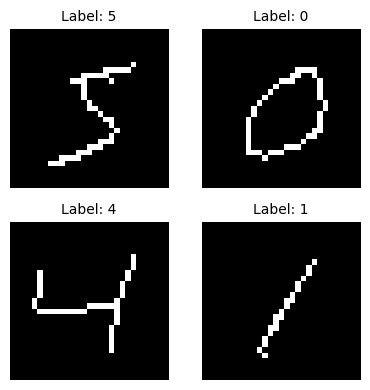

In [5]:
train_dataset.plot_samples(num_samples=4, figsize=(4, 4))

## Model Architecture 🏗️

We'll build a LinOSS model using Linax's configuration system. The model consists of three main components:

1. **Encoder**: Transforms input sequences (4 features) to a higher-dimensional space (64 features)
2. **SSM Blocks**: 4 stacked LinOSS blocks that process the sequences using oscillatory dynamics
3. **Classification Head**: Maps the final representation to class probabilities (10 digits)

### Configuration Parameters:

- `num_blocks=4`: Number of stacked LinOSS layers
- `encoder_config`: Defines the input projection (4 → 64 dimensions)
- `head_config`: Defines the output layer (64 → 10 classes)    

In [ ]:
linoss_cfg = LinOSSConfig(
    num_blocks=NUM_BLOCKS,
    encoder_config=LinearEncoderConfig(in_features=4, out_features=64),
    head_config=ClassificationHeadConfig(out_features=10),
)

In [7]:
key, subkey = jax.random.split(key, 2)

model = linoss_cfg.build(key=subkey)

state = eqx.nn.State(model=model)

### Model Summary 📋

Let's inspect the model to see its architecture and parameter count. 

**What to look for:**
- Total parameters (~100K - lightweight for sequence modeling!)
- Each block has ~25K parameters
- IMEX discretization scheme for numerical stability
- Dropout rate of 0.1 for regularization

In [8]:
print(model)

╔════════════════════════════════════════════════════════════════════════╗
║                           SSM Model Summary                            ║
╠════════════════════════════════════════════════════════════════════════╣
║ Components:                                                            ║
║   Encoder:  LinearEncoder (256 params)                                 ║
║   Blocks:   10× LinOSSBlock (total 250,880 params)                     ║
║     [0] 25,088 params | IMEX | damp:✓ | GLU(64→64) | drop:0.10         ║
║     [1] 25,088 params | IMEX | damp:✓ | GLU(64→64) | drop:0.10         ║
║     [2] 25,088 params | IMEX | damp:✓ | GLU(64→64) | drop:0.10         ║
║     [3] 25,088 params | IMEX | damp:✓ | GLU(64→64) | drop:0.10         ║
║     [4] 25,088 params | IMEX | damp:✓ | GLU(64→64) | drop:0.10         ║
║     [5] 25,088 params | IMEX | damp:✓ | GLU(64→64) | drop:0.10         ║
║     [6] 25,088 params | IMEX | damp:✓ | GLU(64→64) | drop:0.10         ║
║     [7] 25,088 params |

## Loss Function 📉

We use **cross-entropy loss** for multi-class classification, measuring how well the model's predicted probability distribution matches the true labels.

### Implementation Details:

- **Batched computation**: `jax.vmap` processes all samples in parallel for efficiency
- **Stateful forward pass**: Model state (e.g., batch norm statistics) is threaded through computation
- **Axis naming**: `axis_name="batch"` enables collective operations across the batch dimension
- **Returns**: Both the loss value and updated model state (required for stateful layers)

**Expected initial loss:** ~2.3 (log(10)), which corresponds to random guessing among 10 classes.


In [9]:
def loss(
    model: SSM,
    x: Float[Array, "batch 128 4"],
    y: Int[Array, " batch"],
    state: eqx.nn.State,
    key: PRNGKeyArray,
) -> Float[Array, ""]:
    """Apply loss function to the model.

    Returns the cross entropy loss given x and y as well as the updated model state.
    """
    batch_keys = jax.random.split(key, x.shape[0])

    # this vmap parallelizes the model over the batch dimension (which is the first dimension).
    pred_y, model_state = jax.vmap(
        model,
        axis_name="batch",
        in_axes=(0, None, 0),
        out_axes=(0, None),
    )(x, state, batch_keys)
    return cross_entropy(y, pred_y), model_state


def cross_entropy(y: Int[Array, " batch"], pred_y: Float[Array, "batch 10"]) -> Float[Array, ""]:
    """Cross entropy loss function."""
    pred_y = jnp.take_along_axis(pred_y, jnp.expand_dims(y, 1), axis=1)
    return -jnp.mean(pred_y)


# Test the loss function on our sample batch
loss_value, _ = loss(model, dummy_x, dummy_y, state, key)
print(f"Loss shape: {loss_value.shape}")  # Should be scalar ()
print(f"Initial loss value: {loss_value:.4f}")
# Should be around log(10) ≈ 2.3 for random predictions

Loss shape: ()
Initial loss value: 2.2984


### Testing Gradient Computation ✅

Before training, let's verify that gradients flow correctly through the model. We use `eqx.filter_value_and_grad` with `has_aux=True` to compute gradients while also getting the updated model state.

In [10]:
(loss_value, new_state), grads = eqx.filter_value_and_grad(loss, has_aux=True)(
    model, dummy_x, dummy_y, state, key
)

/Users/shox/dev/phd/ssm_dir/linax/.venv/lib/python3.12/site-packages/jax/_src/lax/lax.py:5473: ComplexWarning: Casting complex values to real discards the imaginary part
  x_bar = _convert_element_type(x_bar, x.aval.dtype, x.aval.weak_type)


In [11]:
print(f"Loss after gradient computation: {loss_value:.4f}")

Loss after gradient computation: 2.2984


## Evaluation Metrics 📊

In addition to loss, we track **classification accuracy** to better understand model performance.

### JIT Compilation ⚡:

Both loss and accuracy functions are wrapped with `@eqx.filter_jit` for maximum performance:
- Compiles Python/JAX code to optimized XLA machine code
- First call is slow (compilation), subsequent calls are very fast
- Typical speedup: 10-100x faster than eager execution


In [12]:
loss = eqx.filter_jit(loss)  # JIT our loss function from earlier!


@eqx.filter_jit
def compute_accuracy(
    model: SSM,
    x: Float[Array, "batch 128 4"],
    y: Int[Array, " batch"],
    state: eqx.nn.State,
    key: PRNGKeyArray,
) -> Float[Array, ""]:
    """Computes the average accuracy on a batch."""
    batch_keys = jax.random.split(key, x.shape[0])

    pred_y, _ = jax.vmap(
        model,
        axis_name="batch",
        in_axes=(0, None, 0),
        out_axes=(0, None),
    )(x, state, batch_keys)
    pred_y = jnp.argmax(pred_y, axis=1)
    return jnp.mean(y == pred_y)

### Test Set Evaluation 🧪

This function evaluates the model on the entire test set by iterating through all test batches.

**Inference Mode**: We use `eqx.tree_inference(model, value=True)` to switch to inference mode:
- ✓ Disables dropout (we want deterministic predictions)
- ✓ Uses running statistics for batch normalization (instead of batch statistics)
- ✓ Ensures fair comparison between training and test performance


In [13]:
def evaluate(
    model: SSM,
    testloader: torch.utils.data.DataLoader,
    state: eqx.nn.State,
    key: PRNGKeyArray,
):
    """Evaluates the model on the test dataset."""
    inference_model = eqx.tree_inference(model, value=True)
    avg_loss = 0
    avg_acc = 0
    for x, y in tqdm(testloader, desc="Evaluating"):
        x = x.numpy()
        y = y.numpy()
        # Note that all the JAX operations happen inside `loss` and `compute_accuracy`,
        # and both have JIT wrappers, so this is fast.
        avg_loss += loss(inference_model, x, y, state, key)[0]
        avg_acc += compute_accuracy(inference_model, x, y, state, key)
    return avg_loss / len(testloader), avg_acc / len(testloader)

## Optimizer Setup ⚙️

We use the **AdamW** optimizer from Optax, which is Adam with decoupled weight decay regularization.

**Why AdamW?**
- Better generalization than standard Adam
- Separates weight decay from gradient-based updates
- Well-suited for training SSMs with relatively few parameters
- Learning rate of $3 \times 10^{-4}$ is a good default starting point


In [14]:
optim = optax.adamw(LEARNING_RATE)

## Training Loop 🏋️

Now let's train the model! The training process follows these steps:

1. **Initialize optimizer state** with the model's trainable parameters
2. **Define a single training step** (`make_step`) that:
   - Computes loss and gradients via `eqx.filter_value_and_grad`
   - Updates parameters using the optimizer
   - Returns updated model, optimizer state, loss, and model state
3. **JIT-compile the training step** for maximum performance
4. **Iterate over training data** for the specified number of steps
5. **Evaluate periodically** on the test set to monitor progress

### Performance Optimization ⚡:

The entire training step is wrapped in a single JIT region, ensuring:
- Minimal Python overhead
- Fused operations for efficiency  
- Maximum GPU/TPU utilization

### Expected Results 🎯:

- **Initial accuracy**: ~10% (random guessing among 10 classes)
- **After 300 steps**: ~60-80% (depends on batch size and learning rate)
- **With longer training** (1000+ steps): 95%+ is achievable

Time to train! ☕ This will take a few minutes...


In [15]:
def train(
    model: SSM,
    trainloader: torch.utils.data.DataLoader,
    testloader: torch.utils.data.DataLoader,
    optim: optax.GradientTransformation,
    steps: int,
    print_every: int,
    state: eqx.nn.State,
    key: PRNGKeyArray,
) -> SSM:
    """Trains the model on the training dataset."""
    # Just like earlier: It only makes sense to train the arrays in our model,
    # so filter out everything else.
    opt_state = optim.init(eqx.filter(model, eqx.is_inexact_array))

    # Always wrap everything -- computing gradients, running the optimiser, updating
    # the model -- into a single JIT region. This ensures things run as fast as
    # possible.
    @eqx.filter_jit
    def make_step(
        model: SSM,
        opt_state: PyTree,
        x: Float[Array, "batch 128 4"],
        y: Int[Array, " batch"],
        state: eqx.nn.State,
        key: PRNGKeyArray,
    ):
        (loss_value, new_state), grads = eqx.filter_value_and_grad(loss, has_aux=True)(
            model, x, y, state, key
        )
        updates, opt_state = optim.update(
            grads, opt_state, eqx.filter(model, eqx.is_inexact_array)
        )
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss_value, new_state

    # Loop over our training dataset as many times as we need.
    def infinite_trainloader():
        while True:
            yield from trainloader

    key, train_key = jax.random.split(key, 2)

    for step, (x, y) in zip(tqdm(range(steps)), infinite_trainloader()):
        # PyTorch dataloaders give PyTorch tensors by default,
        # so convert them to NumPy arrays.
        x = x.numpy()
        y = y.numpy()
        model, opt_state, train_loss, new_state = make_step(
            model, opt_state, x, y, state, train_key
        )

        if (step % print_every) == 0 or (step == steps - 1):
            test_loss, test_accuracy = evaluate(model, testloader, new_state, key)
            print(
                f"{step=}, train_loss={train_loss.item()}, "
                f"test_loss={test_loss.item()}, test_accuracy={test_accuracy.item()}"
            )
    return model

In [16]:
model = train(model, trainloader, testloader, optim, STEPS, PRINT_EVERY, state, key)

  0%|          | 2/7500 [00:33<28:42:04, 13.78s/it]

step=0, train_loss=2.26521635055542, test_loss=2.3276331424713135, test_accuracy=0.12140575051307678


 20%|██        | 1502/7500 [04:00<5:24:41,  3.25s/it]

step=1500, train_loss=0.38303691148757935, test_loss=0.29082053899765015, test_accuracy=0.9132388234138489


 40%|████      | 3002/7500 [07:29<4:02:35,  3.24s/it]

...

step=4500, train_loss=0.2860109210014343, test_loss=0.15672750771045685, test_accuracy=0.9519768357276917


 80%|████████  | 6002/7500 [14:28<1:24:21,  3.38s/it]

step=6000, train_loss=0.18842744827270508, test_loss=0.13654617965221405, test_accuracy=0.957068681716919


100%|██████████| 7500/7500 [17:59<00:00,  6.95it/s]

step=7499, train_loss=0.10048183798789978, test_loss=0.13212557137012482, test_accuracy=0.958765983581543


## 🎉 Congratulations!

You've completed the first step on your journey from beginner to hero! 🦸

In this notebook, you learned how to:
- ✅ Load and visualize sequential data (MNIST Sequence dataset)
- ✅ Configure and build a LinOSS model using Linax
- ✅ Set up training with JAX, Equinox, and Optax
- ✅ Train a state space model and monitor its performance

**What's Next?** 🚀

Continue your hero route by exploring the next notebooks, where you'll dive deeper into:
- SSM for regression problems
- Advanced SSM architectures (LRU, S4, S5)
- Configurable SSM architectures

Keep going - you're on your way to mastering State Space Models! 💪


## References

1. **Linax GitHub Repository**: https://github.com/camail-official/linax (⭐ Star the repo!)
2. **LinOSS Paper**: Rusch, T. K., & Rus, D. (2024). "Oscillatory State-Space Models". *arXiv preprint arXiv:2410.03943*. https://arxiv.org/abs/2410.03943
3. **Equinox Documentation**: https://docs.kidger.site/equinox/
4. **JAX Documentation**: https://jax.readthedocs.io/
5. **MNIST SEQUENCE Dataset**: https://edwin-de-jong.github.io/blog/mnist-sequence-data/